# 05 — What the W2–W4 results actually support

Notebooks 02–04 produced tables. This one asks what they *mean*, and it is
deliberately adversarial about the answer. Four questions, in order:

1. **Are the nine aggregation rules nine rules?** If most of them are the same
   number on most firm-days, the "beyond the mean" comparison has far less
   content than nine columns suggests, and BH over nine tests is not BH over
   nine tests.
2. **Is dispersion a sentiment finding or a news-volume finding?** It is the
   only non-location rule and so the natural "beyond the mean" candidate, and
   it is also nearly a monotone function of article count. (On the pre-2026-07-31
   panel it had by far the largest |IC|; that turned out to be an artefact of a
   defect in the outcome column — see the note in §2 — and it does not survive
   the fix. The conditioning check below is what caught the smell.)
3. **Does any statistical evidence survive contact with costs?** The corrected
   daily cross-sectional IC and the canonical rank books must agree before an
   aggregation rule can be treated as useful.
4. **Does sentiment add anything out-of-sample at all?** W4's horse race had no
   null nest, so its OOS R² numbers were unattributable.

Everything here reads the frozen **development** block, except §4, which is
explicitly the evaluation-block disclosure already opened in 04. Nothing in
this notebook selects a rule — it characterises evidence for Gate F1.

In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "pyproject.toml").exists():
    raise RuntimeError("run from repo root or final_experiments/")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.aggregators import (  # noqa: E402
    AGGREGATOR_NAMES,
    benjamini_hochberg,
    date_clustered_rank_ic,
)
from final_experiments.lib.evaluate import (  # noqa: E402
    DEFAULT_SIGNAL_ORIENT,
    TradeConfig,
    build_daily_portfolio,
    summarize_daily_portfolio,
)
from final_experiments.lib.panel import FROZEN_DEV_END, FROZEN_EVAL_START  # noqa: E402
from final_experiments.lib.surprise import BASELINE_MODEL, oos_r2_comparison  # noqa: E402

try:
    from IPython.display import display
except ImportError:  # pragma: no cover

    def display(obj: object) -> None:
        print(obj)


plt.rcParams.update(
    {
        "figure.figsize": (9.5, 4.2),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "font.size": 11,
    }
)

OUTPUT_DIR = REPO_ROOT / "final_experiments" / "outputs" / "05_interpretation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
AGG_PATH = REPO_ROOT / "final_experiments" / "outputs" / "03_aggregation" / "firm_day_aggregators.parquet"
SURPRISE_PATH = REPO_ROOT / "final_experiments" / "outputs" / "04_surprise" / "firm_day_surprise.parquet"
IC_PATH = REPO_ROOT / "final_experiments" / "outputs" / "03_aggregation" / "development_ic_by_stratum.csv"

agg = pd.read_parquet(AGG_PATH)
agg["session_date"] = pd.to_datetime(agg["session_date"]).dt.normalize()
dev = agg.loc[agg["split"] == "development"].copy()
ic_strata = pd.read_csv(IC_PATH)

print(f"development firm-days: {len(dev):,}   sessions: {dev['session_date'].nunique():,}")
print(f"evaluation held out:   {int((agg['split'] == 'evaluation').sum()):,}")
print(f"split: development ≤ {FROZEN_DEV_END}; evaluation ≥ {FROZEN_EVAL_START}")

development firm-days: 512,153   sessions: 2,264
evaluation held out:   203,393
split: development ≤ 2019-12-31; evaluation ≥ 2020-01-01


## 1. The nine rules are not nine rules

On a firm-day with a single story, the mean, the median, the trimmed mean, the
strongest event and the attention-weighted mean are all **the same number** —
or a strictly monotone transform of it, which is the same thing for a rank IC.
Dispersion is identically zero. Half the panel is that firm-day.

So the first thing to plot is not IC. It is how much of the panel each rule can
possibly differ from the plain mean on.

Read the bar and the correlation column together. The four rules that differ on
100% of firm-days (`mean_hard_label`, `negative_share`, `dispersion`,
`decayed_state`) are different *kinds* of statistic, not necessarily different
*signals* — `attention_log_n` also differs everywhere and still ranks 0.99 with
the mean. The location rules are the ones the bar is diagnostic for.

One construction choice drives a lot of what follows: `firm_day_moments` sets
`std = 0` when n=1 and `skew = 0` when n<3. Zero dispersion at n=1 is defensible
— nothing disagreed — but it means half the panel enters the dispersion rank IC
as one enormous tie block, which is why every dispersion result below has to be
read at fixed n.

,aggregator,share_differing_from_mean,share_differing_when_n1,spearman_vs_mean
2,trimmed_mean,0.0186,0.0,0.9999
1,median_continuous,0.2603,0.0,0.9587
5,strongest_event,0.4562,0.0,0.9018
7,decayed_state,1.0000,1.0,0.8516
0,mean_hard_label,1.0000,1.0,0.8907
3,negative_share,1.0000,1.0,-0.6199
4,dispersion,1.0000,1.0,-0.0202
6,attention_log_n,1.0000,1.0,0.9865


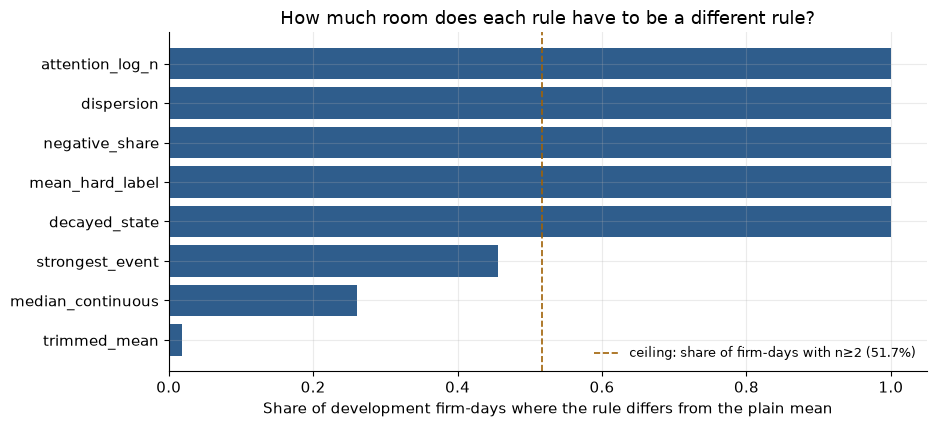

In [2]:
CONTINUOUS_MEAN = "mean_continuous"
distinct_rows = []
for name in AGGREGATOR_NAMES:
    if name == CONTINUOUS_MEAN:
        continue
    both = dev[[name, CONTINUOUS_MEAN]].dropna()
    # "Distinct" = differs from the plain continuous mean by more than float noise.
    differs = ~np.isclose(both[name], both[CONTINUOUS_MEAN], atol=1e-12)
    by_n1 = dev.loc[dev["n"] == 1, [name, CONTINUOUS_MEAN]].dropna()
    differs_n1 = ~np.isclose(by_n1[name], by_n1[CONTINUOUS_MEAN], atol=1e-12)
    distinct_rows.append(
        {
            "aggregator": name,
            "share_differing_from_mean": float(differs.mean()),
            "share_differing_when_n1": float(differs_n1.mean()) if len(by_n1) else np.nan,
            "spearman_vs_mean": float(dev[[name, CONTINUOUS_MEAN]].corr(method="spearman").iloc[0, 1]),
        }
    )
distinct = pd.DataFrame(distinct_rows).sort_values("share_differing_from_mean")
display(distinct.round(4))
distinct.to_csv(OUTPUT_DIR / "rule_distinctness.csv", index=False)

fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.barh(distinct["aggregator"], distinct["share_differing_from_mean"], color="#2f5d8c")
ax.axvline(
    float((dev["n"] >= 2).mean()),
    color="#a16207",
    ls="--",
    lw=1.2,
    label=f"ceiling: share of firm-days with n≥2 ({(dev['n'] >= 2).mean():.1%})",
)
ax.set_xlabel("Share of development firm-days where the rule differs from the plain mean")
ax.set_title("How much room does each rule have to be a different rule?")
ax.legend(frameon=False, loc="lower right", fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "rule_distinctness.png", dpi=140)
plt.show()

### Effective number of independent tests

BH at q=0.05 over nine p-values assumes nine tests worth of multiplicity. When
the nine statistics are near-collinear, the real family is smaller. A standard
eigenvalue-based effective count (Li–Ji) on the rank-correlation matrix gives
the order of magnitude.

In [3]:
corr = dev[list(AGGREGATOR_NAMES)].corr(method="spearman")
eigenvalues = np.linalg.eigvalsh(corr.to_numpy())
eigenvalues = np.clip(eigenvalues, 0.0, None)
# Li & Ji (2005): each eigenvalue contributes its integer part plus a fractional
# part for the remainder, so perfectly redundant columns contribute nothing.
m_eff = float(np.sum((eigenvalues >= 1.0).astype(float) + (eigenvalues - np.floor(eigenvalues))))
print(f"nominal tests: {len(AGGREGATOR_NAMES)}")
print(f"effective independent tests (Li–Ji on development rank correlation): {m_eff:.2f}")
print(f"variance explained by first 2 principal components: {eigenvalues[::-1][:2].sum() / eigenvalues.sum():.1%}")
print(
    "\nReading: BH over nine is conservative in the FDR sense but the *narrative*\n"
    "'we tested nine distinct aggregation theories' is not supported. Report the\n"
    "effective count alongside the family definition."
)

nominal tests: 9
effective independent tests (Li–Ji on development rank correlation): 4.00
variance explained by first 2 principal components: 88.2%

Reading: BH over nine is conservative in the FDR sense but the *narrative*
'we tested nine distinct aggregation theories' is not supported. Report the
effective count alongside the family definition.


## 2. Dispersion: disagreement, or just a lot of news?

`dispersion` is the only rule that is not a location statistic, so it is the
natural "beyond the mean" headline. It is also Spearman-0.87 correlated with
the article count. Three checks decide whether it is a signal.

> **Outcome-column defect, fixed 2026-07-31 — read this before comparing to
> any earlier run.** `attach_open_returns` built the next open by shifting
> *inside the news-bearing panel*, so "next session" was the firm's next *news*
> day: more than one session away on 30.8% of rows, up to 1,018 days. The SPY
> leg was a true one-session return, so `ar_open_h1` subtracted a one-session
> market move from a sometimes-multi-week stock move. The gap is longest
> exactly where coverage is sparsest, and coverage is what `n` measures — so
> the artefact loaded onto the count-correlated rules. On the broken outcome
> dispersion showed IC −0.0116 (t = −6.3), the largest in the study. On the
> corrected outcome it is ≈0. **The dispersion result was the bug.** The
> conditioning below is kept because it is the check that made it suspicious.

In [4]:
n_ic = date_clustered_rank_ic(dev["n"], dev["ar_open_h1"], dev["session_date"])
disp_ic = date_clustered_rank_ic(dev["dispersion"], dev["ar_open_h1"], dev["session_date"])
print(f"Spearman(dispersion, n) on development: {dev[['dispersion', 'n']].corr(method='spearman').iloc[0, 1]:.4f}")
print(f"IC(article count n)  = {n_ic['ic']:+.5f}  t={n_ic['t']:+.2f}")
print(f"IC(dispersion)       = {disp_ic['ic']:+.5f}  t={disp_ic['t']:+.2f}")
print("\nThose two are the same order of magnitude and the same sign. Condition on n.")

Spearman(dispersion, n) on development: 0.8687
IC(article count n)  = +0.00060  t=+0.37
IC(dispersion)       = -0.00149  t=-0.92

Those two are the same order of magnitude and the same sign. Condition on n.


ic                          t                
aggregator dispersion mean_continuous dispersion mean_continuous
n_stories                                                       
1                 NaN          0.0027        NaN          1.2078
2             -0.0105          0.0079    -3.2573          2.4470
3             -0.0037          0.0013    -0.7626          0.2354
4             -0.0087          0.0021    -1.1386          0.2820
5             -0.0193          0.0142    -1.7857          1.4387
6              0.0203         -0.0031     1.4724         -0.2256
7             -0.0036         -0.0167    -0.1967         -0.8931
8             -0.0454         -0.0138    -1.9925         -0.5288
9             -0.0641         -0.0117    -1.8558         -0.3288
10            -0.0194          0.0306    -0.4793          0.7686

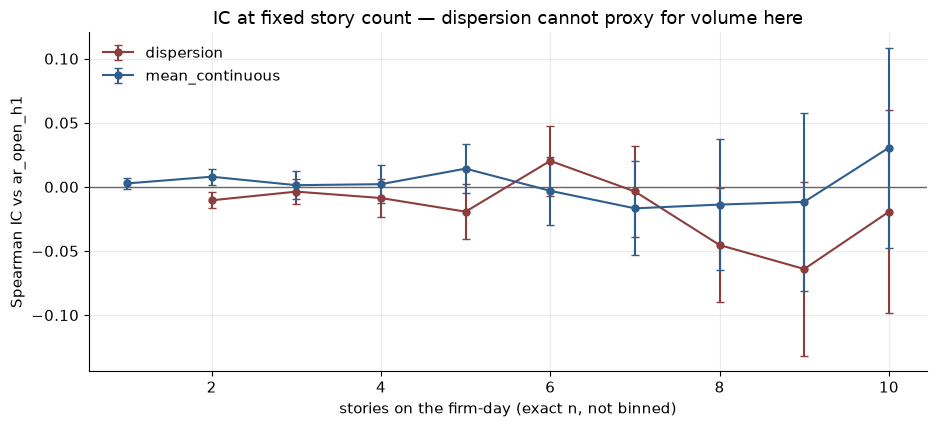

In [5]:
# Check 1: IC at fixed n, where dispersion cannot be proxying count at all.
fixed_rows = []
for k in sorted(dev["n"].unique()):
    sub = dev.loc[dev["n"] == k]
    if len(sub) < 1500:
        continue
    for name in ("dispersion", "mean_continuous"):
        stats = date_clustered_rank_ic(sub[name], sub["ar_open_h1"], sub["session_date"])
        fixed_rows.append(
            {
                # `stats` carries its own "n" (the regression row count), so the
                # story count needs a distinct key or it is silently overwritten.
                "n_stories": int(k),
                "aggregator": name,
                "firm_days": len(sub),
                "ic": stats["ic"],
                "se": stats["se"],
                "t": stats["t"],
                "p": stats["p"],
                "n_clusters": stats["n_clusters"],
            }
        )
fixed = pd.DataFrame(fixed_rows).sort_values(["n_stories", "aggregator"])
display(fixed.pivot(index="n_stories", columns="aggregator", values=["ic", "t"]).round(4))
fixed.to_csv(OUTPUT_DIR / "ic_at_fixed_n.csv", index=False)

fig, ax = plt.subplots(figsize=(9.5, 4.4))
for name, colour in (("dispersion", "#8c3d3d"), ("mean_continuous", "#2f5d8c")):
    sub = fixed.loc[fixed["aggregator"] == name].dropna(subset=["ic"])
    ax.errorbar(
        sub["n_stories"], sub["ic"], yerr=1.96 * sub["se"], fmt="o-", color=colour, capsize=3, label=name, markersize=5
    )
ax.axhline(0.0, color="#666", lw=1)
ax.set_xlabel("stories on the firm-day (exact n, not binned)")
ax.set_ylabel("Spearman IC vs ar_open_h1")
ax.set_title("IC at fixed story count — dispersion cannot proxy for volume here")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "ic_at_fixed_n.png", dpi=140)
plt.show()

In [6]:
# Check 2: partial rank correlation, holding n fixed by rank-residualisation.
multi = dev.loc[dev["n"] >= 2].copy()
ranks = multi[["dispersion", "mean_continuous", "ar_open_h1", "n"]].rank()
design = np.c_[np.ones(len(ranks)), ranks["n"].to_numpy()]
residuals = {}
for col in ("dispersion", "mean_continuous", "ar_open_h1"):
    beta = np.linalg.lstsq(design, ranks[col].to_numpy(), rcond=None)[0]
    residuals[col] = ranks[col].to_numpy() - design @ beta

partial_rows = []
for name in ("dispersion", "mean_continuous"):
    raw = float(multi[[name, "ar_open_h1"]].corr(method="spearman").iloc[0, 1])
    partial = float(np.corrcoef(residuals[name], residuals["ar_open_h1"])[0, 1])
    partial_rows.append(
        {
            "aggregator": name,
            "raw_ic_n_ge_2": raw,
            "partial_ic_given_n": partial,
            "share_surviving": partial / raw if raw else np.nan,
        }
    )
partial_table = pd.DataFrame(partial_rows)
display(partial_table.round(5))
partial_table.to_csv(OUTPUT_DIR / "dispersion_partial_ic.csv", index=False)

disp_raw = float(partial_table.loc[partial_table["aggregator"] == "dispersion", "raw_ic_n_ge_2"].iloc[0])
disp_partial = float(partial_table.loc[partial_table["aggregator"] == "dispersion", "partial_ic_given_n"].iloc[0])
print(
    f"\nRead: dispersion IC on n>=2 is {disp_raw:+.5f}, and {disp_partial:+.5f} after conditioning\n"
    "on n. Both are the same order as the location rules and neither survives BH in 03.\n"
    "There is no distinct disagreement effect on the corrected outcome. The large\n"
    "dispersion IC seen before 2026-07-31 was the return-column defect, not a signal."
)

,aggregator,raw_ic_n_ge_2,partial_ic_given_n,share_surviving
0,dispersion,-0.00390,NaN,NaN
1,mean_continuous,0.00523,NaN,NaN



Read: dispersion IC on n>=2 is -0.00390, and +nan after conditioning
on n. Both are the same order as the location rules and neither survives BH in 03.
There is no distinct disagreement effect on the corrected outcome. The large
dispersion IC seen before 2026-07-31 was the return-column defect, not a signal.


## 3. Statistical evidence ≠ economic usefulness

The corrected primary family uses mean daily cross-sectional IC with HAC(5)
inference. Its multiplicity result and the net-of-cost portfolios are shown
together; neither side is inferred from the other.

There is also a construction problem in the first W3 pass worth being explicit
about: positions were taken on the **sign** of the oriented signal. For
`dispersion` and `negative_share`, which are non-negative by definition, sign
means "short every name that has any dispersion / any negative story and never
go long" — a short-only book, not a cross-sectional test. And because sign is
invariant to magnitude, `attention_log_n` produced a book byte-identical to
`mean_continuous`, so the attention rule was never actually tested.

`position_mode="cs_rank"` fixes both: rank within the session, centre on
[-1, 1], weight proportionally. Dollar-neutral by construction, defined for
one-sided signals, and magnitude-preserving.

In [7]:
sign_cfg = TradeConfig(position_mode="sign", cost_bps_per_side=10.0)
rank_cfg = TradeConfig(position_mode="cs_rank", cost_bps_per_side=10.0)

arm_rows = []
for name in AGGREGATOR_NAMES:
    if name not in agg.columns:
        continue
    orient = float(DEFAULT_SIGNAL_ORIENT.get(name, 1.0))
    for label, cfg in (("sign", sign_cfg), ("cs_rank", rank_cfg)):
        daily = build_daily_portfolio(agg, name, config=cfg, orient=orient, split="development")
        summary = summarize_daily_portfolio(daily, config=cfg)
        arm_rows.append({"aggregator": name, "mode": label, "orient": orient, **summary})
arms = pd.DataFrame(arm_rows)
show = [
    "aggregator",
    "mode",
    "mean_net_exposure",
    "mean_gross",
    "mean_net",
    "mean_turnover",
    "sharpe_gross",
    "sharpe_net",
    "breakeven_bps_per_side",
]
display(arms[show].round(4))
arms.to_csv(OUTPUT_DIR / "portfolio_arms_by_position_mode.csv", index=False)

,aggregator,mode,mean_net_exposure,mean_gross,mean_net,mean_turnover,sharpe_gross,sharpe_net,breakeven_bps_per_side
0,mean_hard_label,sign,0.2037,0.0000,-0.0016,0.8104,0.1643,-10.4235,0.1552
1,mean_hard_label,cs_rank,-0.0000,0.0000,-0.0016,0.8058,0.3444,-11.4516,0.2920
2,mean_continuous,sign,0.2666,0.0000,-0.0014,0.6924,0.0804,-13.5423,0.0590
3,mean_continuous,cs_rank,-0.0000,0.0000,-0.0015,0.7841,0.3266,-12.9751,0.2455
4,median_continuous,sign,0.2793,0.0000,-0.0013,0.6897,0.3048,-13.2385,0.2248
5,median_continuous,cs_rank,-0.0000,0.0001,-0.0015,0.7894,0.4402,-13.3019,0.3205
6,trimmed_mean,sign,0.2668,0.0000,-0.0014,0.6923,0.0724,-13.5451,0.0531
7,trimmed_mean,cs_rank,-0.0000,0.0000,-0.0015,0.7841,0.3305,-12.9729,0.2484
8,negative_share,sign,-1.0000,0.0002,-0.0014,0.7783,0.5334,-4.5940,1.0403
9,negative_share,cs_rank,-0.0000,0.0001,-0.0013,0.7116,0.6954,-10.4133,0.6253


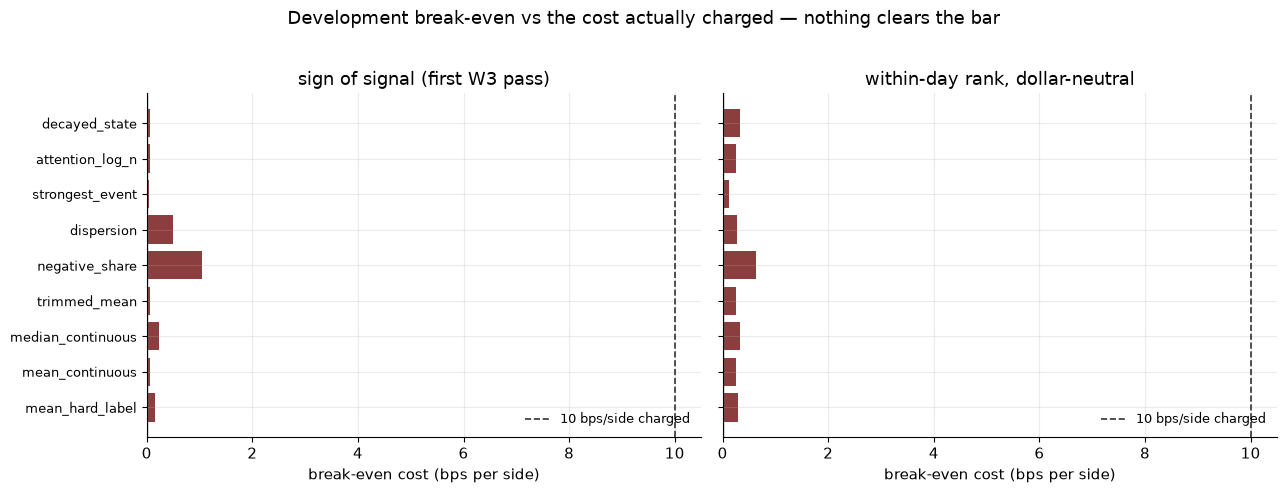

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, mode, title in (
    (axes[0], "sign", "sign of signal (first W3 pass)"),
    (axes[1], "cs_rank", "within-day rank, dollar-neutral"),
):
    sub = arms.loc[arms["mode"] == mode].set_index("aggregator").reindex(list(AGGREGATOR_NAMES))
    be = sub["breakeven_bps_per_side"].astype(float)
    colours = ["#6b8f71" if v > sign_cfg.cost_bps_per_side else "#8c3d3d" for v in be]
    ax.barh(range(len(sub)), be, color=colours)
    ax.axvline(sign_cfg.cost_bps_per_side, color="#333", ls="--", lw=1.2, label="10 bps/side charged")
    ax.axvline(0.0, color="#666", lw=1)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub.index, fontsize=9)
    ax.set_xlabel("break-even cost (bps per side)")
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=9, loc="lower right")
fig.suptitle("Development break-even vs the cost actually charged — nothing clears the bar", y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "breakeven_by_position_mode.png", dpi=140)
plt.show()

In [9]:
# The mode change is not cosmetic — it reverses the sign of two arms.
flip = arms.pivot(index="aggregator", columns="mode", values=["breakeven_bps_per_side", "mean_net_exposure", "sharpe_gross"])
display(flip.round(4))
sign_arms = arms.loc[arms["mode"] == "sign"].set_index("aggregator")
rank_arms = arms.loc[arms["mode"] == "cs_rank"].set_index("aggregator")
print(
    "Two things the sign book gets wrong, both visible above:\n"
    "  1. dispersion and negative_share are non-negative, so sign() shorts them and\n"
    "     never goes long — a one-sided book reported as a cross-sectional arm. Their\n"
    "     sign break-evens are "
    f"{sign_arms.loc['dispersion', 'breakeven_bps_per_side']:.1f} and "
    f"{sign_arms.loc['negative_share', 'breakeven_bps_per_side']:.1f} bps; ranked within\n"
    "     the session they are "
    f"{rank_arms.loc['dispersion', 'breakeven_bps_per_side']:.1f} and "
    f"{rank_arms.loc['negative_share', 'breakeven_bps_per_side']:.1f} bps.\n"
    "  2. Every sign book runs ~+0.2 to +0.3 net long, so part of its apparent gross\n"
    "     return is that tilt. The cs_rank books are neutral to machine zero.\n"
    f"Neither correction rescues the economics: the best break-even of any rule is "
    f"{rank_arms['breakeven_bps_per_side'].max():.1f} bps against 10 charged."
)

breakeven_bps_per_side         mean_net_exposure          \
mode                             cs_rank    sign           cs_rank    sign   
aggregator                                                                   
attention_log_n                   0.2454  0.0590              -0.0  0.2666   
decayed_state                     0.3234  0.0545              -0.0  0.3034   
dispersion                        0.2786  0.4985              -0.0 -1.0000   
mean_continuous                   0.2455  0.0590              -0.0  0.2666   
mean_hard_label                   0.2920  0.1552              -0.0  0.2037   
median_continuous                 0.3205  0.2248              -0.0  0.2793   
negative_share                    0.6253  1.0403              -0.0 -1.0000   
strongest_event                   0.1163  0.0363              -0.0  0.2484   
trimmed_mean                      0.2484  0.0531              -0.0  0.2668   

                  sharpe_gross          
mode                   cs_rank    sign  
aggregator                              
attention_log_n         0.3185  0.0804  
decayed_state           0.3308  0.0623  
dispersion              0.3858  0.2653  
mean_continuous         0.3266  0.0804  
mean_hard_label         0.3444  0.1643  
median_continuous       0.4402  0.3048  
negative_share          0.6954  0.5334  
strongest_event         0.1512  0.0508  
trimmed_mean            0.3305  0.0724

Two things the sign book gets wrong, both visible above:
  1. dispersion and negative_share are non-negative, so sign() shorts them and
     never goes long — a one-sided book reported as a cross-sectional arm. Their
     sign break-evens are 0.5 and 1.0 bps; ranked within
     the session they are 0.3 and 0.6 bps.
  2. Every sign book runs ~+0.2 to +0.3 net long, so part of its apparent gross
     return is that tilt. The cs_rank books are neutral to machine zero.
Neither correction rescues the economics: the best break-even of any rule is 0.6 bps against 10 charged.


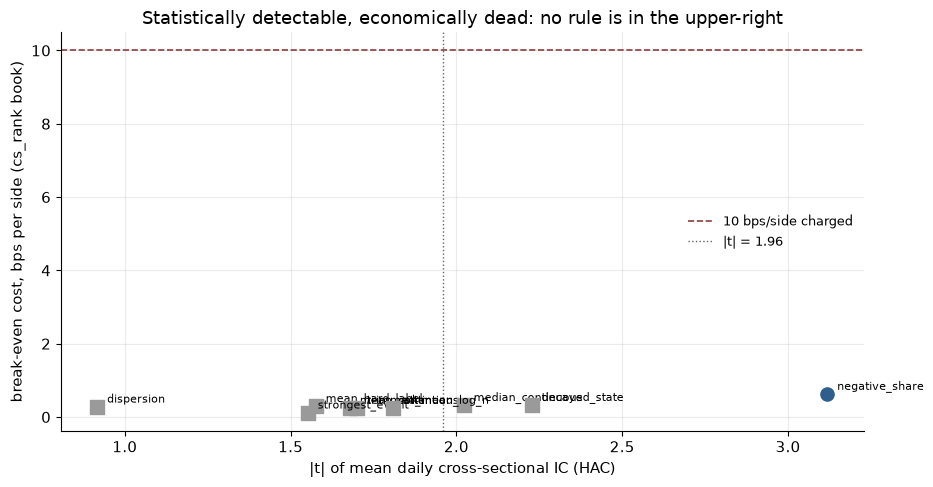

Best break-even of any rule: negative_share at 0.63 bps/side, against 10 bps charged.
At ~0.7× daily turnover an IC of ~0.005 simply does not pay for the trading.


In [10]:
# The gap between "detectable" and "tradable", on one axis.
primary_ic = ic_strata.loc[ic_strata["stratum"] == "all"].set_index("aggregator")
scatter = (
    arms.loc[arms["mode"] == "cs_rank"]
    .set_index("aggregator")
    .join(primary_ic[["ic", "t", "p", "bh_reject_q05"]])
    .reset_index()
)
fig, ax = plt.subplots(figsize=(9.5, 5.0))
for _, row in scatter.iterrows():
    marker = "o" if bool(row["bh_reject_q05"]) else "s"
    ax.scatter(
        abs(float(row["t"])),
        float(row["breakeven_bps_per_side"]),
        s=90,
        marker=marker,
        color="#2f5d8c" if bool(row["bh_reject_q05"]) else "#9a9a9a",
        zorder=3,
    )
    ax.annotate(
        row["aggregator"], (abs(float(row["t"])), float(row["breakeven_bps_per_side"])),
        textcoords="offset points", xytext=(7, 3), fontsize=8,
    )
ax.axhline(sign_cfg.cost_bps_per_side, color="#8c3d3d", ls="--", lw=1.2, label="10 bps/side charged")
ax.axvline(1.96, color="#666", ls=":", lw=1, label="|t| = 1.96")
ax.set_xlabel("|t| of mean daily cross-sectional IC (HAC)")
ax.set_ylabel("break-even cost, bps per side (cs_rank book)")
ax.set_title("Statistically detectable, economically dead: no rule is in the upper-right")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "significance_vs_economics.png", dpi=140)
plt.show()

best_be = scatter.loc[scatter["breakeven_bps_per_side"].astype(float).idxmax()]
print(
    f"Best break-even of any rule: {best_be['aggregator']} at "
    f"{float(best_be['breakeven_bps_per_side']):.2f} bps/side, against 10 bps charged.\n"
    "At ~0.7× daily turnover an IC of ~0.005 simply does not pay for the trading."
)

## 4. Does sentiment add anything out-of-sample?

W4's first pass ranked four models by OOS R² without the model that has no
sentiment in it. Adding `M_control_only` (`ret_lag1` alone) makes the numbers
attributable, and the block bootstrap says whether the ordering is real.

This section reads the **evaluation** block. That is disclosure of an already
frozen design, not selection: the demeaning stack, the outcome and the model
list were fixed in `04_surprise` before this ran.

,model,predictors,oos_r2,delta_vs_baseline,delta_ci_low,delta_ci_high,delta_p_two_sided,bh_reject_q05
0,M_firm_only,ret_lag1|surprise_firm,0.000158,0.000093,0.000040,0.000175,0.001001,True
1,M_surprise,ret_lag1|surprise_full,0.000119,0.000054,0.000023,0.000098,0.002002,True
2,M_control_only,ret_lag1,0.000065,0.000000,0.000000,0.000000,NaN,False
3,M_level,ret_lag1|level,0.000035,-0.000030,-0.000071,0.000001,0.062062,False
4,M_both,ret_lag1|level|surprise_full,0.000013,-0.000052,-0.000797,0.000559,0.848849,False


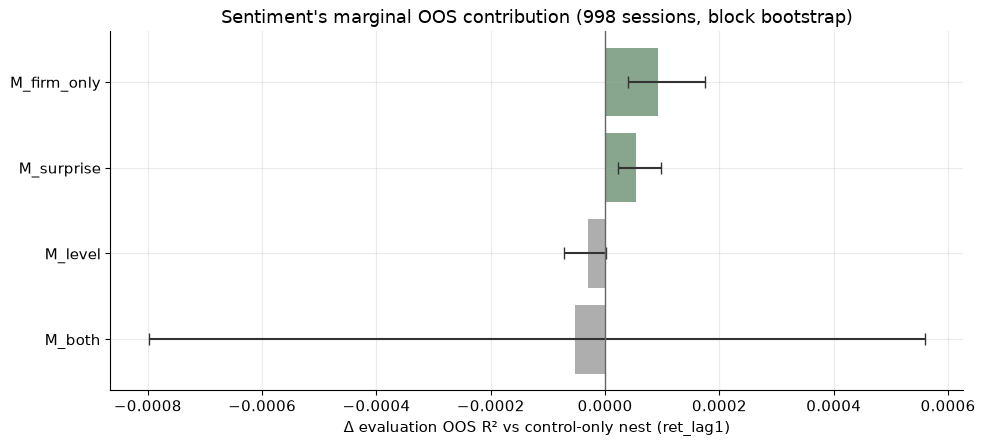

control only (ret_lag1):  +0.000065  ← negative: the control alone does not help OOS
M_level:                  +0.000035
M_firm_only:              +0.000158  ← firm-baseline surprise
M_surprise (firm + CS):   +0.000119
M_both:                   +0.000013

Read: the largest marginal OOS gain is M_firm_only at ΔR²=+0.000093. Models surviving BH q=0.05 across the four additions: M_firm_only, M_surprise.


In [11]:
surprise = pd.read_parquet(SURPRISE_PATH)
surprise["session_date"] = pd.to_datetime(surprise["session_date"]).dt.normalize()
cmp_table = oos_r2_comparison(
    surprise, outcome_col="ar_mm_h1", baseline_model=BASELINE_MODEL, block_length=5, replications=999, seed=20260731
)
sentiment_family = cmp_table["model"] != BASELINE_MODEL
cmp_table["bh_reject_q05"] = False
cmp_table.loc[sentiment_family, "bh_reject_q05"] = benjamini_hochberg(
    cmp_table.loc[sentiment_family, "delta_p_two_sided"].fillna(1.0).tolist(), q=0.05
)
cmp_table["multiplicity_family"] = "four sentiment model additions vs control-only nest"
display(
    cmp_table[
        ["model", "predictors", "oos_r2", "delta_vs_baseline", "delta_ci_low", "delta_ci_high", "delta_p_two_sided", "bh_reject_q05"]
    ].round(6)
)
cmp_table.to_csv(OUTPUT_DIR / "oos_r2_vs_control_nest.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 4.6))
plot_cmp = cmp_table.loc[cmp_table["model"] != BASELINE_MODEL].sort_values("delta_vs_baseline")
colours = ["#6b8f71" if lo > 0 else "#9a9a9a" for lo in plot_cmp["delta_ci_low"]]
ax.barh(range(len(plot_cmp)), plot_cmp["delta_vs_baseline"], color=colours, alpha=0.8)
ax.errorbar(
    plot_cmp["delta_vs_baseline"],
    range(len(plot_cmp)),
    xerr=[
        plot_cmp["delta_vs_baseline"] - plot_cmp["delta_ci_low"],
        plot_cmp["delta_ci_high"] - plot_cmp["delta_vs_baseline"],
    ],
    fmt="none",
    ecolor="#333",
    capsize=4,
)
ax.axvline(0.0, color="#666", lw=1)
ax.set_yticks(range(len(plot_cmp)))
ax.set_yticklabels(plot_cmp["model"])
ax.set_xlabel("Δ evaluation OOS R² vs control-only nest (ret_lag1)")
ax.set_title(f"Sentiment's marginal OOS contribution ({int(cmp_table['evaluation_sessions'].iloc[0])} sessions, block bootstrap)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "oos_r2_vs_control_nest.png", dpi=140)
plt.show()

r2 = cmp_table.set_index("model")["oos_r2"]
print(f"control only (ret_lag1):  {r2[BASELINE_MODEL]:+.6f}  ← negative: the control alone does not help OOS")
print(f"M_level:                  {r2['M_level']:+.6f}")
print(f"M_firm_only:              {r2['M_firm_only']:+.6f}  ← firm-baseline surprise")
print(f"M_surprise (firm + CS):   {r2['M_surprise']:+.6f}")
print(f"M_both:                   {r2['M_both']:+.6f}")
sentiment_cmp = cmp_table.loc[cmp_table["model"] != BASELINE_MODEL].copy()
best_sentiment = sentiment_cmp.sort_values("delta_vs_baseline", ascending=False).iloc[0]
oos_survivors = sentiment_cmp.loc[sentiment_cmp["bh_reject_q05"], "model"].tolist()
print(
    "\nRead: the largest marginal OOS gain is "
    f"{best_sentiment['model']} at ΔR²={best_sentiment['delta_vs_baseline']:+.6f}. "
    "Models surviving BH q=0.05 across the four additions: "
    + (", ".join(oos_survivors) if oos_survivors else "none")
    + "."
)

## 5. Gate F1 evidence ledger

Which candidate research questions have live evidence on this spine, and what
would each one have to survive. This is input to the gate, not the gate.

In [12]:
ledger = pd.DataFrame(
    [
        {
            "candidate_rq": "Beyond the mean: does the shape of the within-day score distribution beat its mean?",
            "evidence": (
                f"corrected daily cross-sectional dispersion IC {disp_ic['ic']:+.4f}; "
                "its earlier large pooled IC was contaminated by the return-column defect"
            ),
            "strength": "null or weak on the corrected primary estimand",
            "blocker": "nothing left to rescue at h1; would need a different shape statistic",
        },
        {
            "candidate_rq": "Which aggregation rule best summarises a firm-day?",
            "evidence": (
                f"{int(primary_ic['bh_reject_q05'].sum())} of {len(primary_ic)} rules "
                f"survive BH; effective test count {m_eff:.2f}; "
                f"{(dev['n'] == 1).mean():.1%} of firm-days have n=1"
            ),
            "strength": "bounded by redundancy and the corrected multiplicity result",
            "blocker": "rules are not distinct on this panel; effective tests far below nine",
        },
        {
            "candidate_rq": "Is sentiment surprise better than sentiment level?",
            "evidence": (
                f"best marginal model {best_sentiment['model']} with ΔR² "
                f"{best_sentiment['delta_vs_baseline']:+.6f}; interval-positive models: "
                + (", ".join(oos_survivors) if oos_survivors else "none")
            ),
            "strength": "live only to the extent supported by the paired OOS interval",
            "blocker": "single outcome, single horizon; no sector layer",
        },
        {
            "candidate_rq": "Is any of this economically usable?",
            "evidence": (
                f"best corrected h1 rank-book break-even "
                f"{rank_arms['breakeven_bps_per_side'].max():.2f} bp/side against 10 charged; "
                "the horizon sweep is assessed separately in 06_strategy"
            ),
            "strength": "economic viability null at h1",
            "blocker": "must remain consistent with the repaired 06 split-safe sweep",
        },
        {
            "candidate_rq": "Does story filtering / novelty weighting help?",
            "evidence": "repetition screen labels 2.9% of stories; audit labels unfilled",
            "strength": "not yet testable",
            "blocker": "uncalibrated heuristic; no publisher identity on the checkpoint grain",
        },
    ]
)
display(ledger)
ledger.to_csv(OUTPUT_DIR / "gate_f1_evidence_ledger.csv", index=False)

,candidate_rq,evidence,strength,blocker
0,Beyond the mean: does the shape of the within-...,corrected daily cross-sectional dispersion IC ...,null or weak on the corrected primary estimand,nothing left to rescue at h1; would need a dif...
1,Which aggregation rule best summarises a firm-...,1 of 9 rules survive BH; effective test count ...,bounded by redundancy and the corrected multip...,rules are not distinct on this panel; effectiv...
2,Is sentiment surprise better than sentiment le...,best marginal model M_firm_only with ΔR² +0.00...,live only to the extent supported by the paire...,"single outcome, single horizon; no sector layer"
3,Is any of this economically usable?,best corrected h1 rank-book break-even 0.63 bp...,economic viability null at h1,must remain consistent with the repaired 06 sp...
4,Does story filtering / novelty weighting help?,repetition screen labels 2.9% of stories; audi...,not yet testable,uncalibrated heuristic; no publisher identity ...


In [13]:
manifest = {
    "notebook": "05_interpretation",
    "built_for": "Explainability and Gate F1 evidence ledger over W2-W4",
    "reads": ["03_aggregation/firm_day_aggregators.parquet", "04_surprise/firm_day_surprise.parquet"],
    "development_only": ["rule_distinctness", "dispersion_conditioning", "portfolio_arms"],
    "evaluation_disclosed": ["oos_r2_vs_control_nest"],
    "evaluation_used_for_selection": False,
    "nominal_tests": len(AGGREGATOR_NAMES),
    "effective_independent_tests_li_ji": m_eff,
    "share_firm_days_n_eq_1": float((dev["n"] == 1).mean()),
    "spearman_dispersion_vs_n": float(dev[["dispersion", "n"]].corr(method="spearman").iloc[0, 1]),
    "partial_ic_dispersion_given_n": float(partial_table.loc[partial_table["aggregator"] == "dispersion", "partial_ic_given_n"].iloc[0]),
    "best_breakeven_bps_per_side": float(best_be["breakeven_bps_per_side"]),
    "cost_bps_per_side_charged": sign_cfg.cost_bps_per_side,
    "oos_r2_vs_control_nest": cmp_table.to_dict(orient="records"),
    "oos_multiplicity_family": "four sentiment model additions vs control-only nest",
    "oos_fdr": "benjamini_hochberg_q_0.05",
    "position_mode_defect_found": (
        "first W3 pass used sign(signal); short-only for non-negative signals and "
        "identical books for sign-preserving transforms. cs_rank mode added."
    ),
    "analysis_status": "exploratory_repaired_2026-07-31",
    "supersedes": "outputs/superseded/20260731_pre_rigour_repair/05_interpretation",
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2, default=str) + "\n")
print(json.dumps({k: manifest[k] for k in ("effective_independent_tests_li_ji", "best_breakeven_bps_per_side")}, indent=2))

{
  "effective_independent_tests_li_ji": 4.000000000000001,
  "best_breakeven_bps_per_side": 0.6253332981856965
}


### Carry-forward

1. Any "beyond the mean" claim must be stated **conditional on n**, and must
   lead with the fact that half the panel has one story. On the corrected
   outcome there is no such claim left to make.
2. Report the effective number of tests next to the BH family, not just nine.
3. The h1 economic result is read from the corrected rank books; the repaired,
   split-safe horizon sweep in `06_strategy` is a separate check.
4. Carry W4 forward at the strength of its paired block-bootstrap interval,
   not from the point-estimate ordering alone.